<a href="https://colab.research.google.com/github/Piramu-Mahalingam/DS-Course-Assignment-1/blob/main/Cryptocurrency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from pandas import DataFrame
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15,7)

import seaborn as sns
from datetime import datetime, timedelta

from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from scipy import stats
import statsmodels.api as sm
from itertools import product

import warnings
warnings.filterwarnings('ignore')

In [6]:
from datetime import datetime

# Define date parser correctly
dateparse = lambda dates: datetime.strptime(dates, '%Y-%m-%d')

# Read the CSV file
df = pd.read_csv("/content/crypto-markets.csv", parse_dates=['date'])
df.head()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.30,135.98,132.10,134.21,0,1.500520e+09,0.5438,3.88
1,bitcoin,BTC,Bitcoin,2013-04-29,1,134.44,147.49,134.00,144.54,0,1.491160e+09,0.7813,13.49
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.00,146.93,134.05,139.00,0,1.597780e+09,0.3843,12.88
3,bitcoin,BTC,Bitcoin,2013-05-01,1,139.00,139.89,107.72,116.99,0,1.542820e+09,0.2882,32.17
4,bitcoin,BTC,Bitcoin,2013-05-02,1,116.38,125.60,92.28,105.21,0,1.292190e+09,0.3881,33.32


In [7]:
df.tail()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
702161,ocow,OCOW,OCOW,2018-01-02,1516,0.000014,0.000030,0.000013,0.000015,733,0.0,0.1176,0.0
702162,ocow,OCOW,OCOW,2018-01-03,1516,0.000015,0.000031,0.000015,0.000015,1200,0.0,0.0,0.0
702163,ocow,OCOW,OCOW,2018-01-04,1516,0.000015,0.000031,0.000015,0.000030,5375,0.0,0.9375,0.0
702164,ocow,OCOW,OCOW,2018-01-05,1516,0.000030,0.000032,0.000016,0.000017,1922,0.0,0.0625,0.0
702165,ocow,OCOW,OCOW,2018-01-06,1516,0.000017,0.000017,0.000016,0.000017,1884,0.0,1.0,0.0


In [10]:
# Extract the bitcoin data only
btc=df[df['symbol']=='BTC']
# Drop some columns
btc.drop(['slug', 'volume','symbol','name','ranknow','market', 'close_ratio', 'spread'],axis=1,inplace=True)
btc.head()

,date,open,high,low,close
0,2013-04-28,135.30,135.98,132.10,134.21
1,2013-04-29,134.44,147.49,134.00,144.54
2,2013-04-30,144.00,146.93,134.05,139.00
3,2013-05-01,139.00,139.89,107.72,116.99
4,2013-05-02,116.38,125.60,92.28,105.21


In [ ]:
# Lets take just the last year
#btc = btc.loc['2013']
#btc.shape

In [15]:
import pandas as pd

# Assuming your DataFrame is 'btc' and has a 'Date' column
btc['date'] = pd.to_datetime(btc['date'])  # convert to datetime
btc.set_index('date', inplace=True)        # set as index

# Resample to monthly frequency and take the mean
btc_month = btc.resample('M').mean()

# Optional: display the first few rows
print(btc_month.head())

                  open        high         low       close
date                                                      
2013-04-30  137.913333  143.466667  133.383333  139.250000
2013-05-31  120.292258  123.949032  114.253548  119.993226
2013-06-30  108.856333  111.300667  104.602333  107.761333
2013-07-31   90.311613   93.869032   86.719355   90.512258
2013-08-31  113.041935  116.002258  111.388065  113.905161


Dickey–Fuller test: p=0.998818


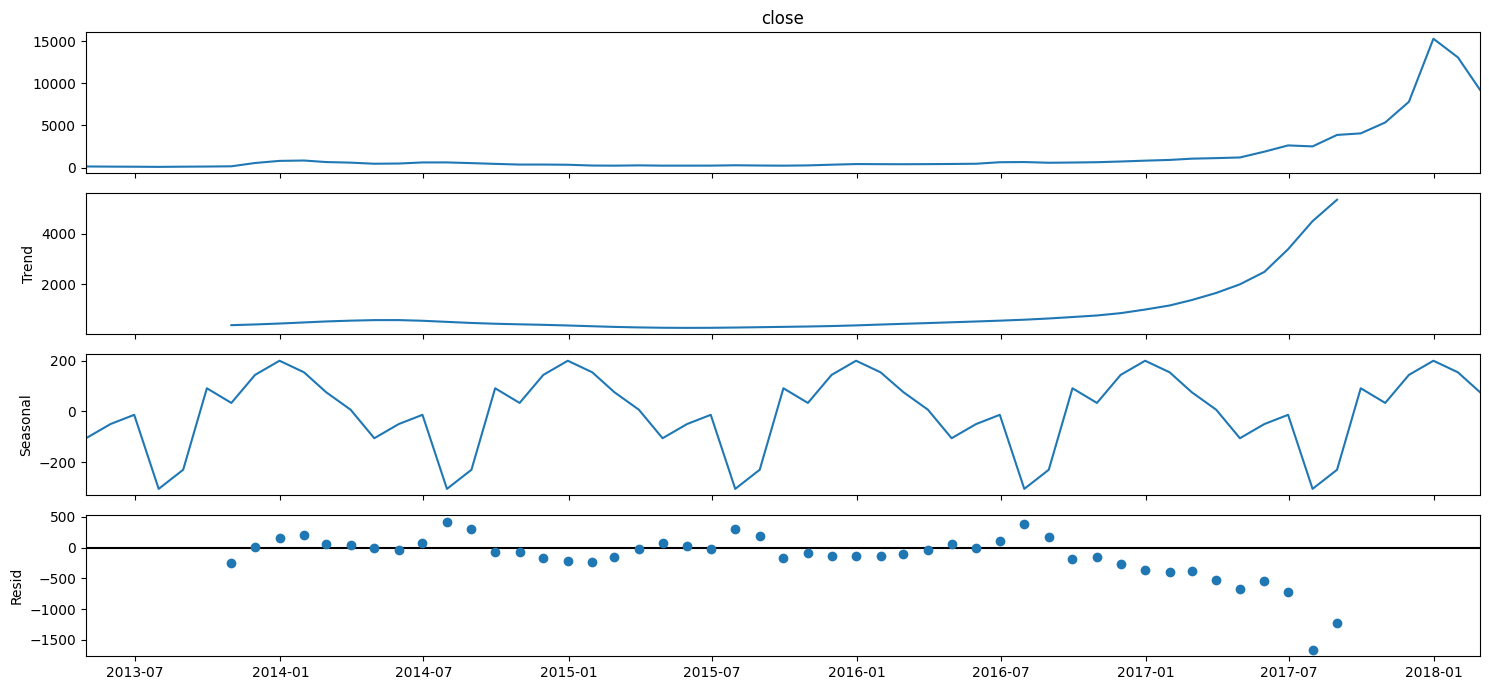

In [16]:
#seasonal_decompose(btc_month.close, freq=12).plot()
seasonal_decompose(btc_month.close).plot()
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.close)[1])
plt.show()

In [17]:
# Box-Cox Transformations
btc_month['close_box'], lmbda = stats.boxcox(btc_month.close)
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.close_box)[1])

Dickey–Fuller test: p=0.513639


In [18]:
# Seasonal differentiation (12 months)
btc_month['box_diff_seasonal_12'] = btc_month.close_box - btc_month.close_box.shift(12)
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.box_diff_seasonal_12[12:])[1])

Dickey–Fuller test: p=0.666118


In [19]:
# Seasonal differentiation (3 months)
btc_month['box_diff_seasonal_3'] = btc_month.close_box - btc_month.close_box.shift(3)
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.box_diff_seasonal_3[3:])[1])

Dickey–Fuller test: p=0.017880


Dickey–Fuller test: p=0.002295


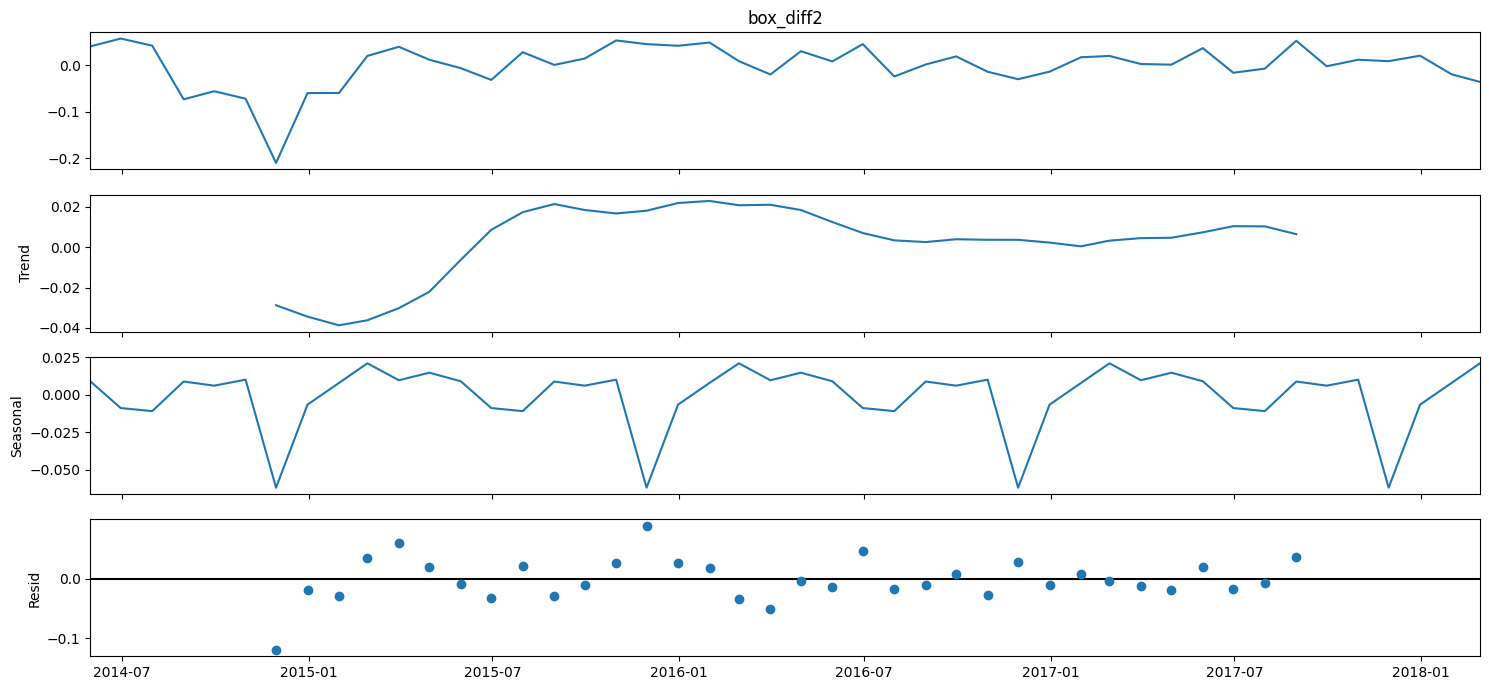

In [20]:
# Regular differentiation
btc_month['box_diff2'] = btc_month.box_diff_seasonal_12 - btc_month.box_diff_seasonal_12.shift(1)

# STL-decomposition
seasonal_decompose(btc_month.box_diff2[13:]).plot()
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.box_diff2[13:])[1])

plt.show()

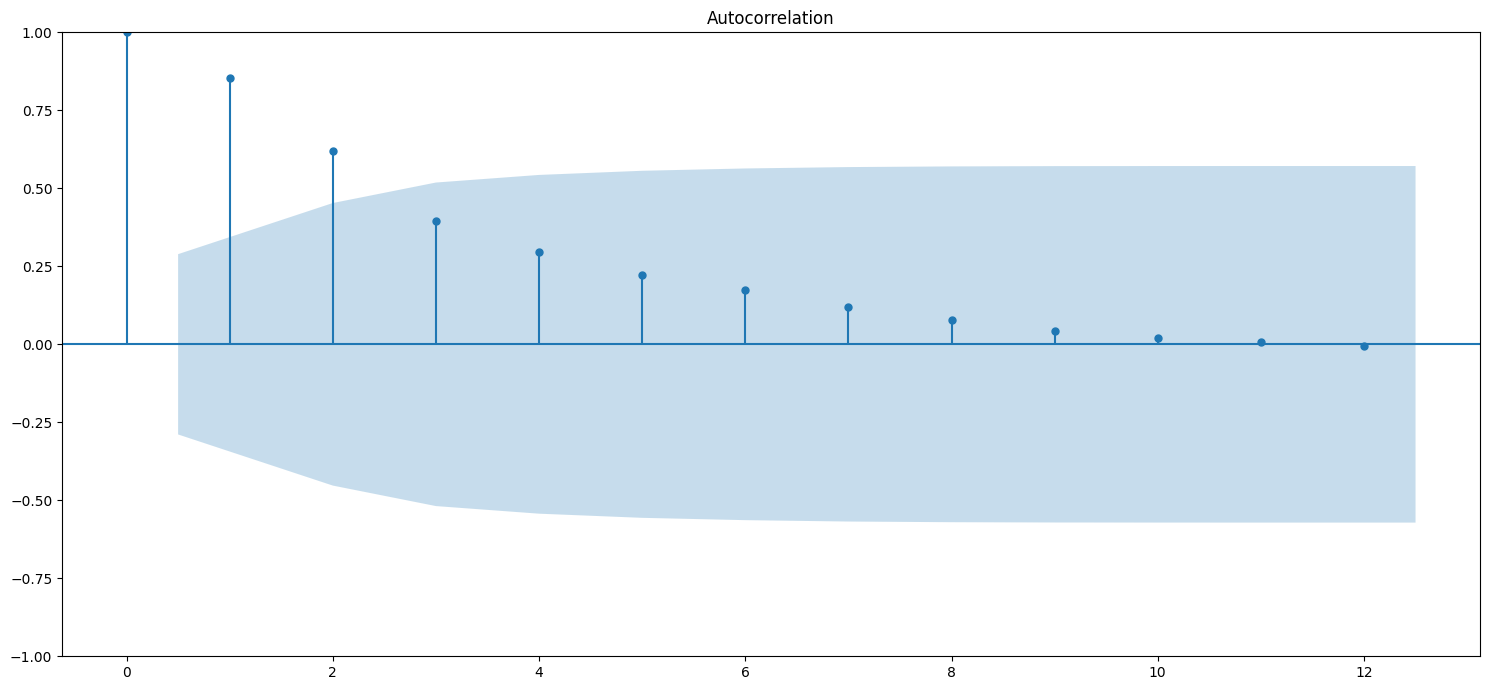

In [21]:
#autocorrelation_plot(btc_month.close)
plot_acf(btc_month.close[13:].values.squeeze(), lags=12)

plt.tight_layout()
plt.show()

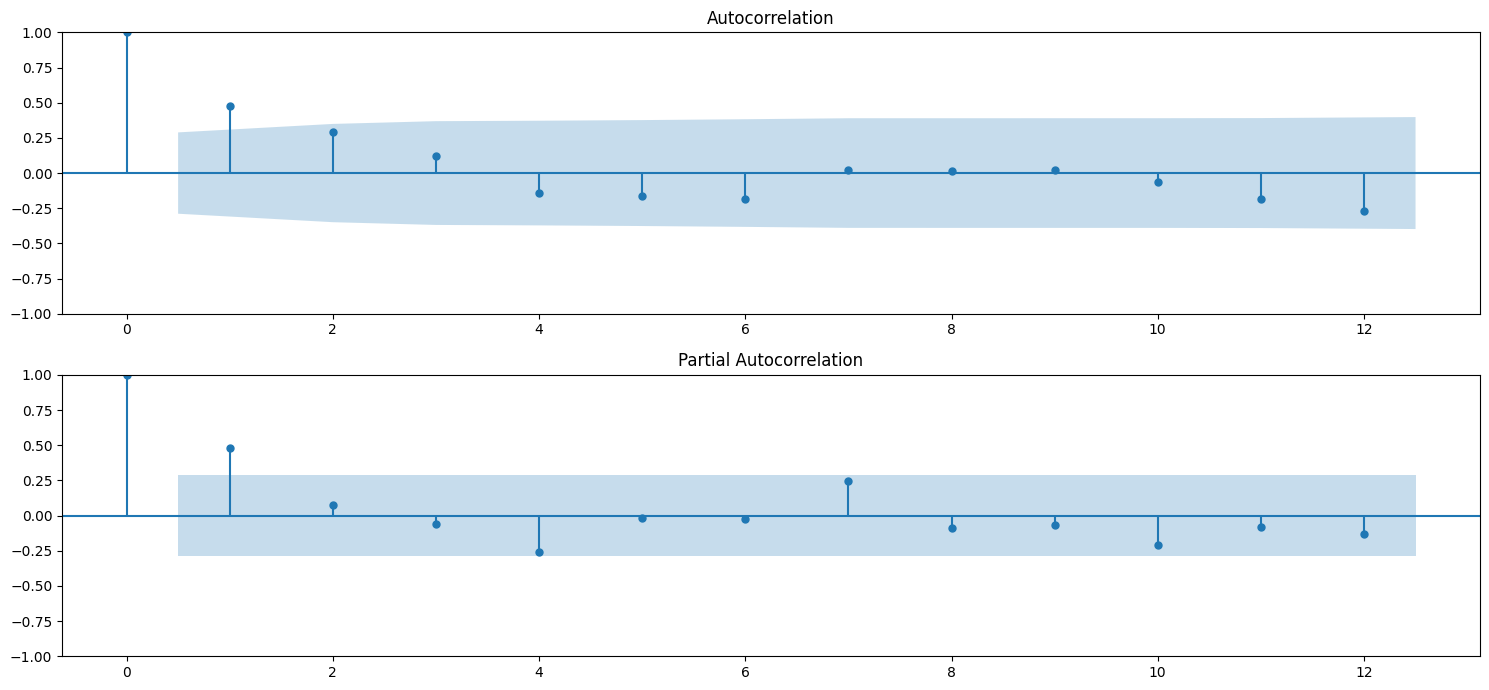

In [22]:
# Initial approximation of parameters using Autocorrelation and Partial Autocorrelation Plots
ax = plt.subplot(211)
# Plot the autocorrelation function
#sm.graphics.tsa.plot_acf(btc_month.box_diff2[13:].values.squeeze(), lags=48, ax=ax)
plot_acf(btc_month.box_diff2[13:].values.squeeze(), lags=12, ax=ax)
ax = plt.subplot(212)
#sm.graphics.tsa.plot_pacf(btc_month.box_diff2[13:].values.squeeze(), lags=48, ax=ax)
plot_pacf(btc_month.box_diff2[13:].values.squeeze(), lags=12, ax=ax)
plt.tight_layout()
plt.show()

In [25]:
# Initial approximation of parameters
qs = range(0, 3)
ps = range(0, 3)
d=1
parameters = product(ps, qs)
parameters_list = list(parameters)
len(parameters_list)

# Model Selection
results = []
best_aic = float("inf")
warnings.filterwarnings('ignore')
for param in parameters_list:
    try:
        model = SARIMAX(btc_month.close_box, order=(param[0], d, param[1])).fit(disp=-1)
    except ValueError:
        print('bad parameter combination:', param)
        continue
    aic = model.aic
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])
results

[[(0, 0), np.float64(-214.53318260893624)],
 [(0, 1), np.float64(-220.80337792792187)],
 [(0, 2), np.float64(-219.0027992526492)],
 [(1, 0), np.float64(-221.18783692888903)],
 [(1, 1), np.float64(-219.22746936445364)],
 [(1, 2), np.float64(-217.27558739733018)],
 [(2, 0), np.float64(-219.21800229329318)],
 [(2, 1), np.float64(-217.74091566160823)],
 [(2, 2), np.float64(-215.81160767695957)]]

In [26]:
# Best Models
result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'aic']
print(result_table.sort_values(by = 'aic', ascending=True).head())

  parameters         aic
3     (1, 0) -221.187837
1     (0, 1) -220.803378
4     (1, 1) -219.227469
6     (2, 0) -219.218002
2     (0, 2) -219.002799


In [27]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:              close_box   No. Observations:                   59
Model:               SARIMAX(1, 1, 0)   Log Likelihood                 112.594
Date:                Tue, 14 Oct 2025   AIC                           -221.188
Time:                        09:24:37   BIC                           -217.067
Sample:                    04-30-2013   HQIC                          -219.583
                         - 02-28-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3737      0.151      2.471      0.013       0.077       0.670
sigma2         0.0012      0.000     11.243      0.000       0.001       0.001
Ljung-Box (L1) (Q):                   0.02   Jarque-

In [28]:
print("Dickey–Fuller test:: p=%f" % adfuller(best_model.resid[13:])[1])

Dickey–Fuller test:: p=0.005647


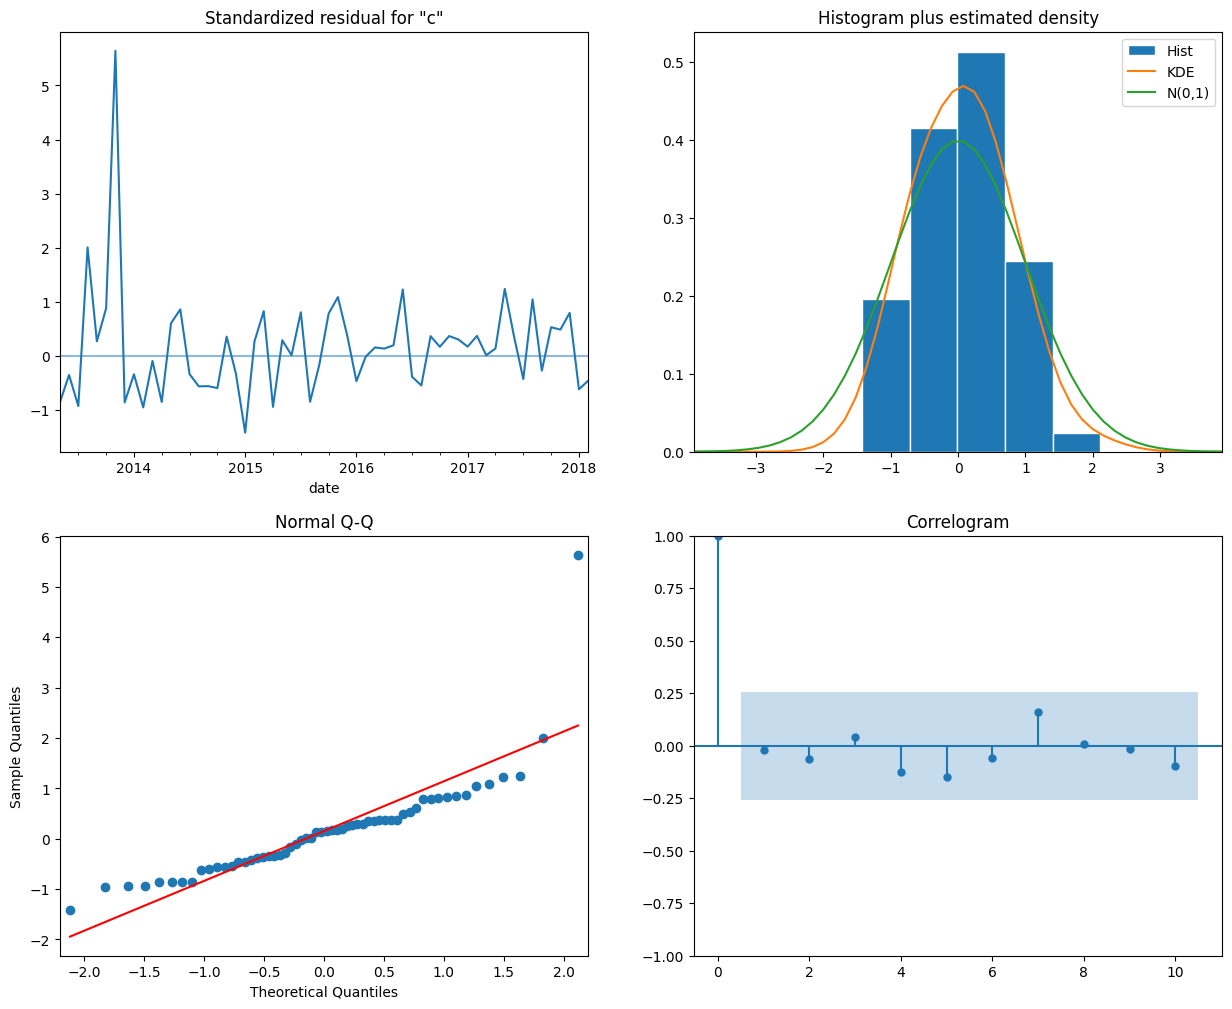

In [29]:
best_model.plot_diagnostics(figsize=(15, 12))
plt.show()

In [30]:
# Inverse Box-Cox Transformation Function
def invboxcox(y,lmbda):
   if lmbda == 0:
      return(np.exp(y))
   else:
      return(np.exp(np.log(lmbda*y+1)/lmbda))

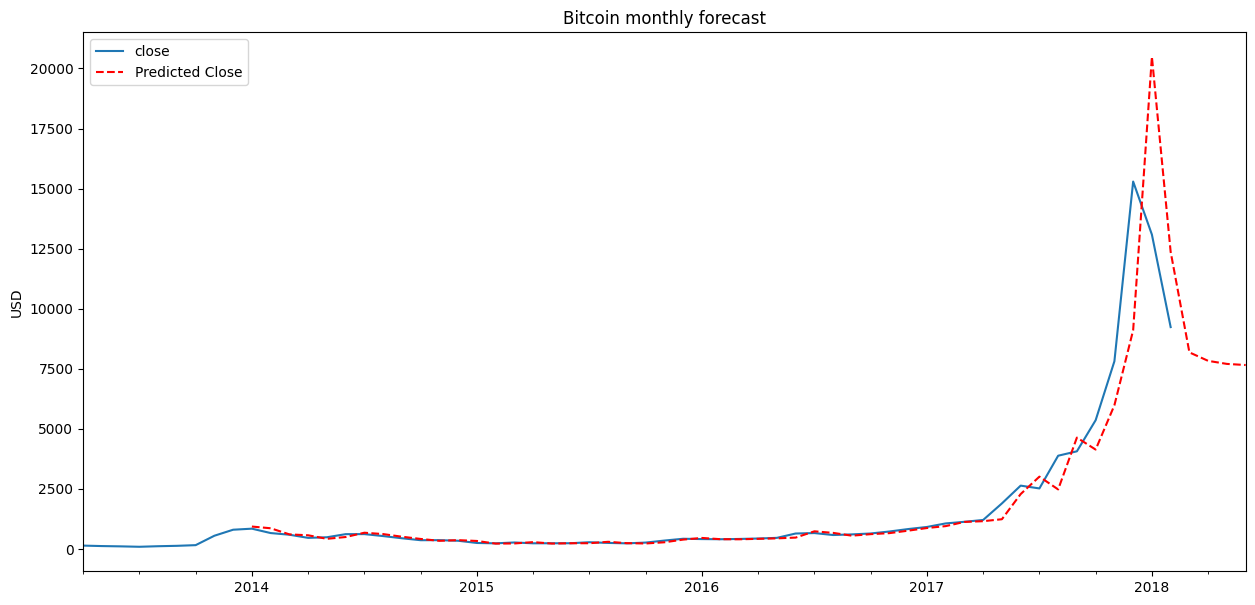

In [31]:
# Prediction
btc_month_pred = btc_month[['close']]
#date_list = [datetime(2018, 3, 31), datetime(2018, 4, 30), datetime(2018, 5, 31), datetime(2018, 6, 30),
#             datetime(2018, 7, 31), datetime(2018, 8, 31), datetime(2018, 9, 30), datetime(2018, 10, 31),
#             datetime(2018, 11, 30), datetime(2018, 12, 31)]
date_list = [datetime(2018, 3, 31), datetime(2018, 4, 30), datetime(2018, 5, 31), datetime(2018, 6, 30)]
future = pd.DataFrame(index=date_list, columns= btc_month.columns)
btc_month_pred = pd.concat([btc_month_pred, future])

#btc_month_pred['forecast'] = invboxcox(best_model.predict(start=0, end=75), lmbda)
btc_month_pred['forecast'] = invboxcox(best_model.predict(start=datetime(2014, 1, 31), end=datetime(2018, 6, 30)), lmbda)


plt.figure(figsize=(15,7))
btc_month_pred.close.plot()
btc_month_pred.forecast.plot(color='r', ls='--', label='Predicted Close')
plt.legend()
plt.title('Bitcoin monthly forecast')
plt.ylabel('USD')
plt.show()

In [33]:
# Initial approximation of parameters
Qs = range(0, 2)
qs = range(0, 3)
Ps = range(0, 3)
ps = range(0, 3)
D=1
d=1
parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

# Model Selection
results = []
best_aic = float("inf")
warnings.filterwarnings('ignore')
for param in parameters_list:
    try:
#        model = SARIMAX(btc_month.close_box, order=(param[0], d, param[1]), seasonal_order=(param[2], D, param[3], 12)).fit(disp=-1)
        model = SARIMAX(btc_month.close_box, order=(param[0], d, param[1]), seasonal_order=(param[2], D, param[3], 4)).fit(disp=-1)
    except ValueError:
        print('bad parameter combination:', param)
        continue
    aic = model.aic
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])
results

[[(0, 0, 0, 0), np.float64(-156.02533683220145)],
 [(0, 0, 0, 1), np.float64(-188.80290772038023)],
 [(0, 0, 1, 0), np.float64(-181.89500065408723)],
 [(0, 0, 1, 1), np.float64(-188.45386254392724)],
 [(0, 0, 2, 0), np.float64(-183.06793672053072)],
 [(0, 0, 2, 1), np.float64(-186.70404402841413)],
 [(0, 1, 0, 0), np.float64(-161.52190318115422)],
 [(0, 1, 0, 1), np.float64(-193.18670766120917)],
 [(0, 1, 1, 0), np.float64(-184.23443267527037)],
 [(0, 1, 1, 1), np.float64(-193.2422639800508)],
 [(0, 1, 2, 0), np.float64(-187.93398344851477)],
 [(0, 1, 2, 1), np.float64(-191.6041274937978)],
 [(0, 2, 0, 0), np.float64(-160.25529224430267)],
 [(0, 2, 0, 1), np.float64(-191.46097678085619)],
 [(0, 2, 1, 0), np.float64(-182.38331135837575)],
 [(0, 2, 1, 1), np.float64(-191.5691459920768)],
 [(0, 2, 2, 0), np.float64(-186.8634091868984)],
 [(0, 2, 2, 1), np.float64(-190.07806730828585)],
 [(1, 0, 0, 0), np.float64(-161.82887607602837)],
 [(1, 0, 0, 1), np.float64(-193.70014871749456)],
 [(1

In [34]:
# Best Models
result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'aic']
print(result_table.sort_values(by = 'aic', ascending=True).head())
print(best_model.summary())

      parameters         aic
21  (1, 0, 1, 1) -194.119126
49  (2, 2, 0, 1) -193.843219
19  (1, 0, 0, 1) -193.700149
9   (0, 1, 1, 1) -193.242264
7   (0, 1, 0, 1) -193.186708
                                      SARIMAX Results                                      
Dep. Variable:                           close_box   No. Observations:                   59
Model:             SARIMAX(1, 1, 0)x(1, 1, [1], 4)   Log Likelihood                 101.060
Date:                             Tue, 14 Oct 2025   AIC                           -194.119
Time:                                     09:34:32   BIC                           -186.163
Sample:                                 04-30-2013   HQIC                          -191.051
                                      - 02-28-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------

In [ ]:
#https://www.kaggle.com/code/taniaj/cryptocurrency-predictions-with-arima/notebook